GRPO 算法全称是Group Relative Policy Optimization ，
- <font color='red'>是一种针对无需奖励的强化学习人类反馈（RLHF）任务的算法。<font>

https://mp.weixin.qq.com/s/S_mRoz6UQnsIwrAOu-iZdQ?clicktag=bar_share&scene=1&clickpos=7376&from_safari=0

- 其核心思想是通过**分组相对策略优化**来改进模型的表现。
- 其实它的精髓很简单：

  - 不靠“打分”这种绝对评价
  - 靠“谁比谁强”这种相对排序
  - <font color='red'>把策略分组，在组内选最强<font>

<font color='red'>组与组之间还能同时探索多种风格，避免大家全扎堆做水煮肉片。<font>

GRPO 就像一个聪明的、不靠嘴巴靠眼神评菜的大厨。它不需要你给个“你这道菜80分”，它只要知道“你这道比那道更讨喜”，它就能一步步变得更强。

### 原来这就是GRPO
- 如果把大型语言模型比作一群正在参加辩论大赛的聪明小伙伴，以前的做法是请一个严厉的裁判（外部评估者）来打分、点评，告诉大家谁表现好谁该回家反思。结果大家说话都小心翼翼，还得时刻看裁判脸色，进步慢得像蜗牛爬。

- GRPO 的做法就不一样了，它直接取消了那个碎碎念的裁判！<font color='red'>改成让小伙伴们自己组团互评。<font> 
    - 比如，一群人围坐成圈，一人发表观点，剩下的人开始点评：“你这个想法新颖！”、“这个推理有点绕啊！”、“妙啊，妙不可言！”——大家相互较劲、相互激发灵感，比谁的思路更清晰、更有说服力。
    - 这种“没有裁判，自带竞技场”的模式，让大伙在互相较量中不断成长。因为不再拘泥于讨好裁判，他们能更自由地探索复杂问题，还能锻炼出一口气把长难题说清楚的超强推理能力！
    - 所以说，GRPO就像是给大脑开了一场没有终点的思维马拉松，跑着跑着，模型的脑瓜子就越来越灵光啦！你说，这种“内卷式进化”，谁能不爱呢？

### 下图是 PPO和GRPO的一个图示：

In [1]:
from IPython.display import Image

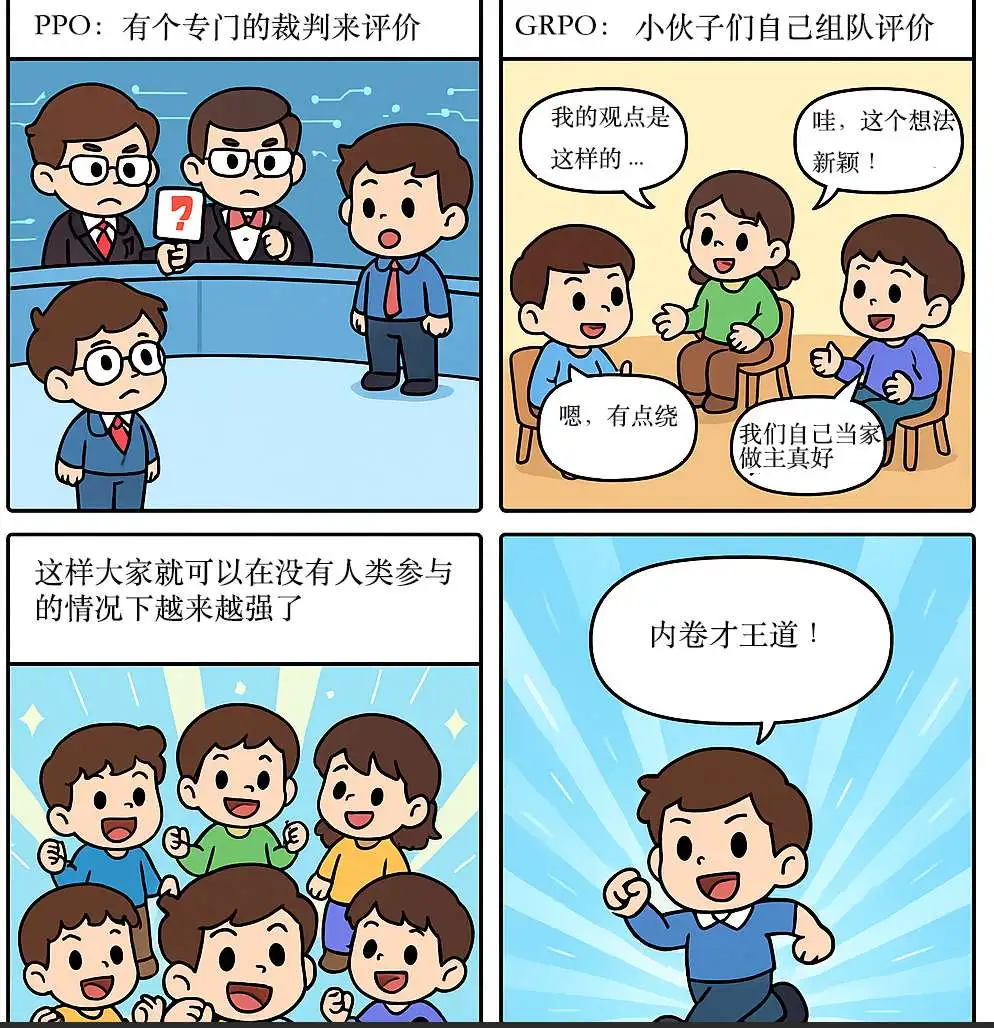

In [9]:
Image(filename='./image/ppo_pic.png',width=500)

#### GRPO 的创新在于它打破了传统强化学习对奖励信号的依赖，通过组内相对策略优化来实现模型的自我提升。
- 这一创新点使得GRPO在无需明确奖励信号的场景下仍能进行有效学习，极大地拓展了强化学习的应用范围。

在 GRPO 算法中，<font color='red'>每个小组内的模型策略都会相互比较，通过相对排序来找出当前组内最优的策略。<font>
- 这种组内竞争机制促使模型不断尝试新的策略组合，以在组内脱颖而出。

#### 下图是它们两者的区别：

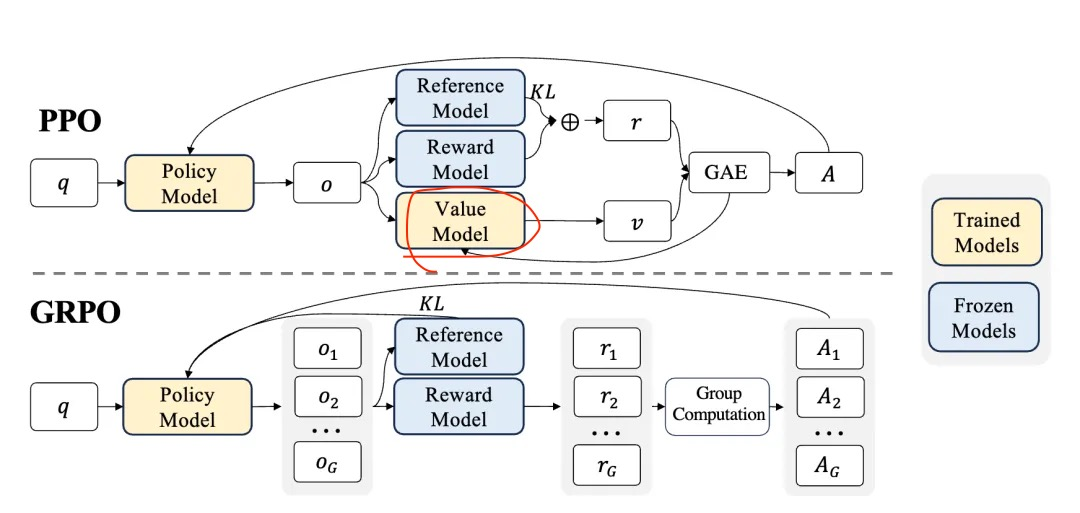

In [31]:
Image(filename='./image/PPO_GRPO.png')

#### GRPO 是不同组之间相互比较：

GRPO算法就像小朋友们分组玩游戏，不看谁得分高，只看谁比谁更厉害。每组小朋友都比着谁更聪明，想出好办法。这样，大家玩着玩着就变得更聪明了，就像大脑开了场思维马拉松！

<font color='red'>哪组表现好，哪组就能拿到最高奖。<font>

GRPO 通过对各组得分进行排序，就像小朋友们分组玩游戏，不比谁得分高，只比谁想法好。每组都想出好办法，玩着玩着大家就更聪明了。这就是GRPO算法，让模型在玩游戏中变得更厉害！

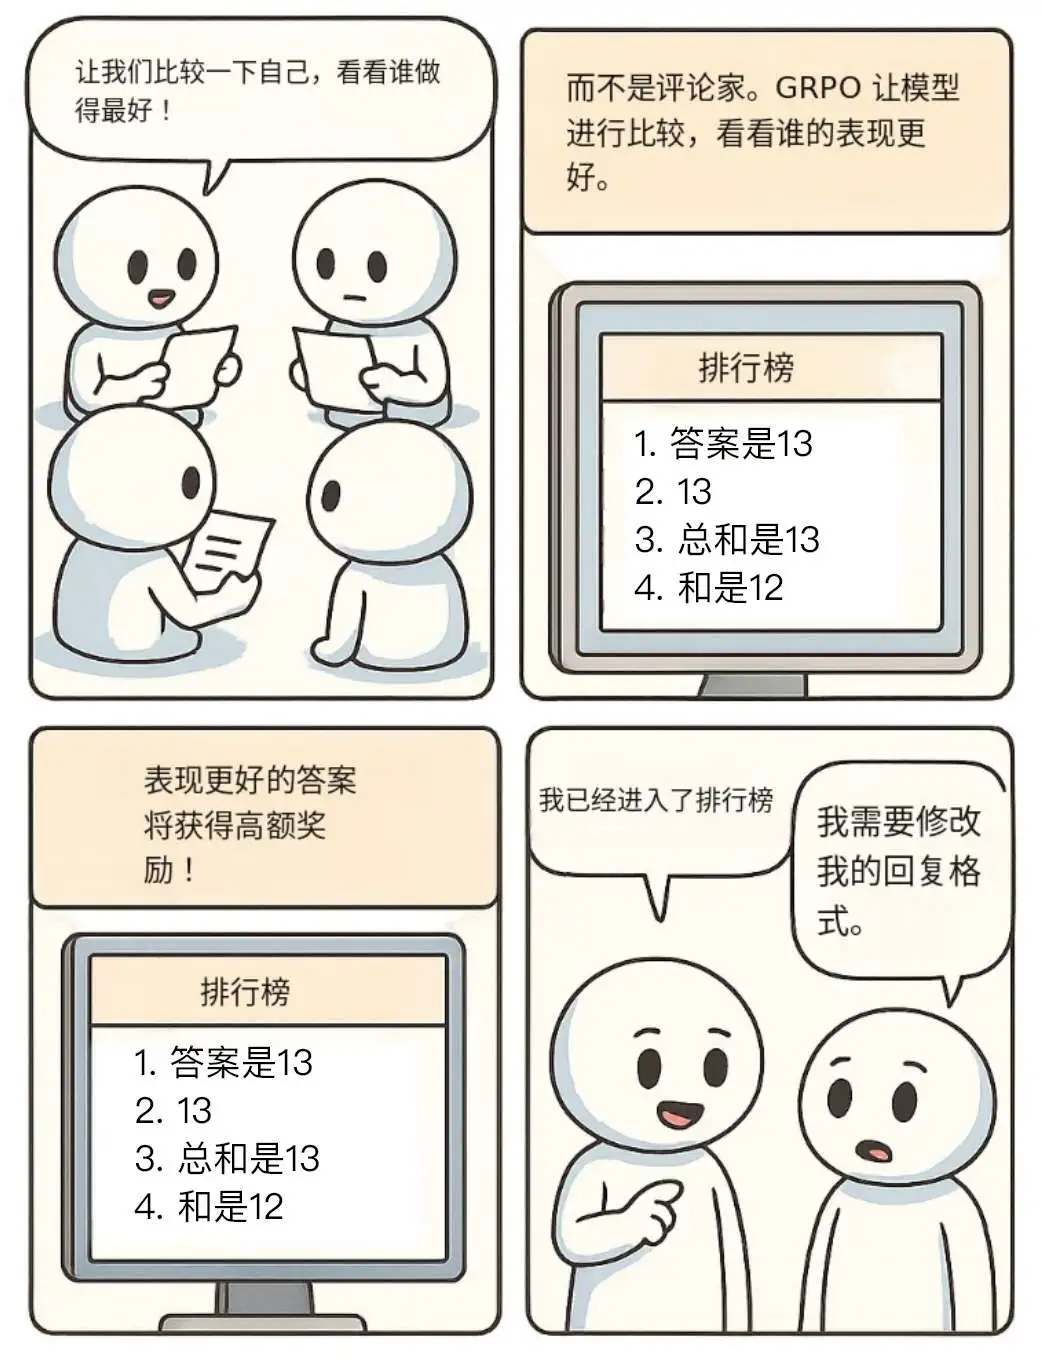

In [10]:
Image(filename='./image/grpo_comp.png',width=500)

### 纸上推演： GRPO的数学推演

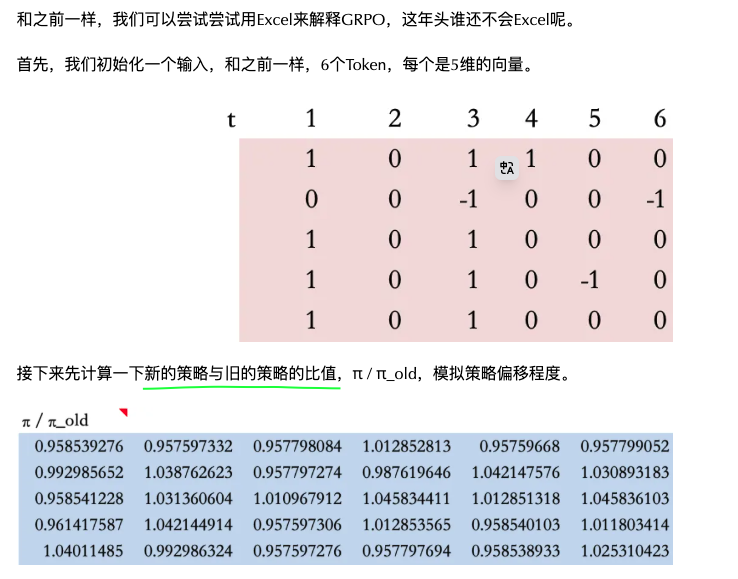

In [14]:
Image(filename='./image/grpo_01.png',width=600)

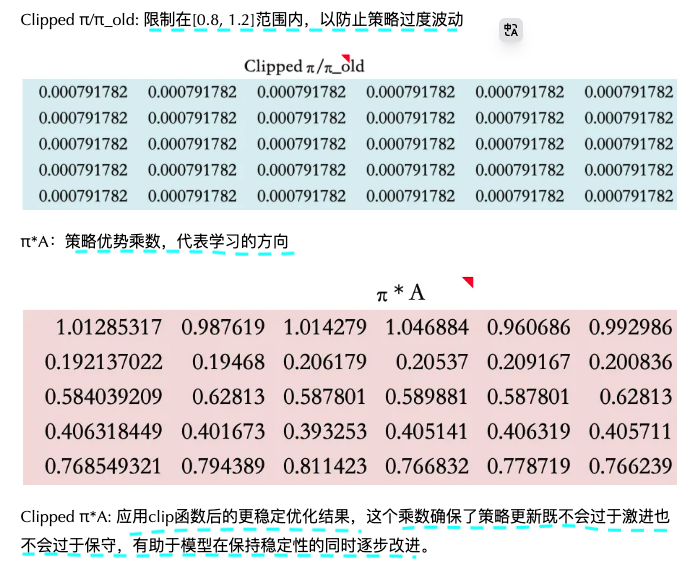

In [15]:
Image(filename='./image/grpo_02.png',width=600)

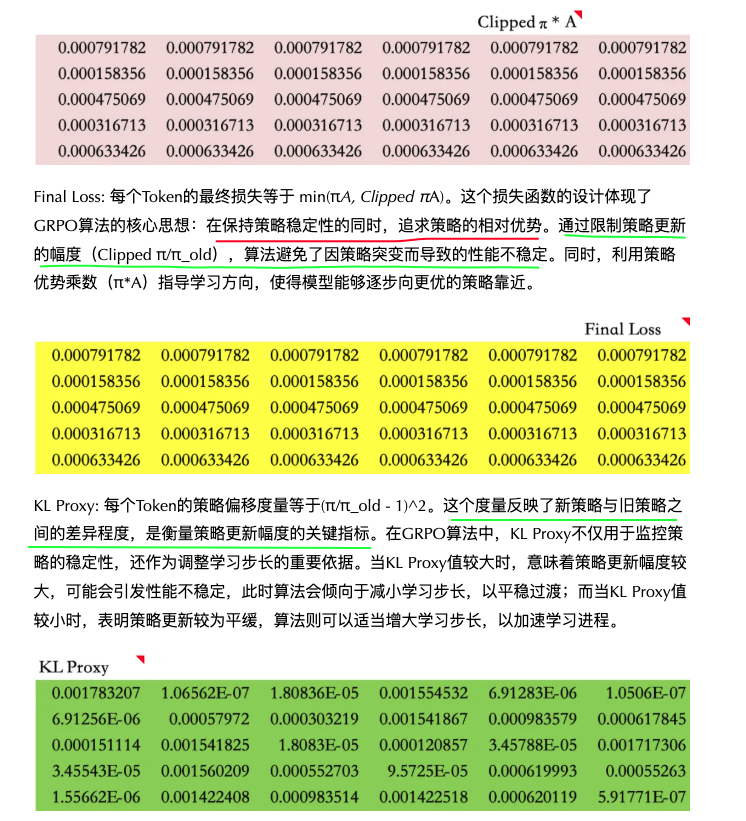

In [20]:
Image(filename='./image/grpo_03.png',width=600)

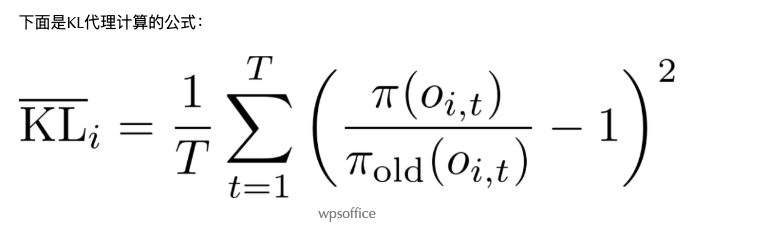

In [22]:
Image(filename='./image/kl_proxy.png',width=600)

- $π(o_i，t)表示在状态t下采取动作O_i的新策略概率$

- $π_{old}((o_i，t)表示在状态t下采取动作O_i的旧策略概率$

- Σ表示对所有可能的状态和动作进行求和。

<font color='red'>这个公式计算了每个状态下每个动作的新旧策略概率比值的平方差之和，从而量化了策略更新的幅度。<font>

- 通过监控KL Proxy值的变化，算法能够动态调整学习步长，确保策略更新的稳定性和有效性。

下面是针对输入的Token的计算结果：

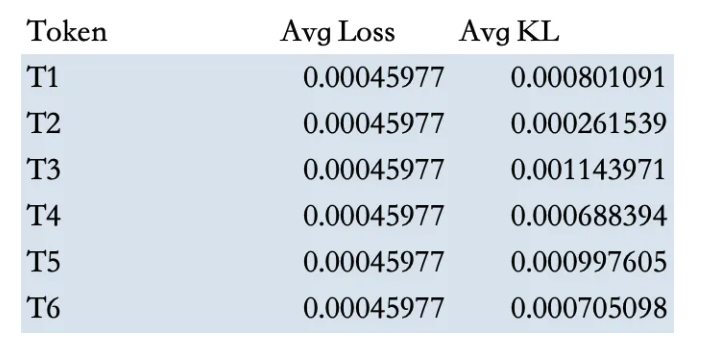

In [23]:
Image(filename='./image/avg_kl.png',width=500)

- 平均 Loss: 所有为 0.00045977

- 平均 KL : ≈ (0.0008011 + 0.0002615 + 0.001144 + 0.000688 + 0.000998 + 0.000705) / 6 ≈ 0.0007662

- 最终计算得出：GRPO = 0.00045977 - 0.1 * 0.0007662 ≈ 0.00038315

嘿，各位，看到这里有何感想？在本节中，我们运用了名为GRPO的算法对模型进行了一次小规模的“优化”，结果如何呢？确实，平均损失又悄然下降了一些！这可是在缺乏奖励信号的情况下实现的，必须承认，GRPO算法在强化学习领域确实显示出了它的独特优势。

### GRPO的代码实现

- 组相对策略优化的核心理念在于评价你的表现，并非基于绝对的优秀程度，而是基于你相较于同组成员的相对优势。

#### 为何这种方法更聪明？

- 在传统的 AI 训练模式中，模型是独立工作的，它只专注于提升自身的性能。
- 然而，在 GRPO 中，模型被划分为若干个“专家组”，每个小组都有其独特的评价标准。

#### 这样做有什么益处？

✅ 促进多样性，认识到并非只有完全一致的表现才是优秀；

✅ 实现更稳定的学习过程，避免被少数表现突出的“尖子生”所左右。

下让我们用 Python 来模拟一下！接下来将编写一段简洁的代码，通过类比的方式展示 GRPO 的工作原理。



In [19]:

# 导入 PyTorch 库

import torch
from torch.distributions import Categorical
import torch.nn as nn
import torch.optim as optim

# 策略网络
# 定义一个“学生模型”，用于根据输入状态选择一个动作（例如选择题选项）
class StudentModel(nn.Module):
    def __init__(self):
        super(StudentModel, self).__init__()
        self.fc = nn.Linear(4, 3)  # 输入4个知识点熟练度，输出3个动作的logits

    def forward(self, state):
        return torch.softmax(self.fc(state), dim=-1)

# 生成交互数据：
# 模拟一次考试：让模型对100道题目做出选择
# 这就是策略梯度算法的采样过程，采集(状态-动作-回报) 的三元组，构成经验数据。
def take_exam(model):
    records = []
    for _ in range(100):
        state = torch.rand(4)  # 模拟一个4维状态（知识点掌握度）
        probs = model(state)
        # 用于从一组概率中抽样 —— 类比“学生在多个选项中选择答案”。
        dist = Categorical(probs)
        action = dist.sample()
        
        score = torch.rand(1).item()  # 模拟得分（0~1）
        
        # 记录状态、动作、此时的对数概率分布、得分
        records.append((state, action, dist.log_prob(action), score))
    
    return records

# 计算相对优势（Advantage）
# 计算相对得分（优势值）：每个得分减去平均分
'''
这里就是GRPO的“组内对比”机制，用的是优势函数 A(s, a)。

高于平均水平的表现会得到正的优势奖励，低于平均水平的表现产生负反馈。

直观理解：

“考得比班级平均分高” → 奖励大；

“考得比平均分低” → 下次要改进。
'''
def compute_relative_score(records):
    scores = torch.tensor([r[3] for r in records])
    baseline = scores.mean() # 小组平均水平（基线）
    return scores - baseline  # 相对优势 Advantage = Reward - Baseline

# 策略优化：
# 使用相对优势优化模型参数（策略梯度 + PPO 风格 clip）
'''
采用了 PPO（Proximal Policy Optimization） 的核心思想 —— 剪切目标函数，防止剧烈更新。

ratio = π_new / π_old：策略改进幅度比值。

torch.clamp(ratio, 0.8, 1.2)：限制每次更新在 ±20% 以内，保证学习稳定。

为什么要乘以 adv？

正的 Advantage → 鼓励这个动作（增大概率）；

负的 Advantage → 惩罚这个动作（减少概率）。

'''

def optimize_model(model, records, relative_scores):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    # adv 相对优势
    for (state, action, old_log_prob, _), adv in zip(records, relative_scores):
        # 确保输入是张量
        state = torch.tensor(state, dtype=torch.float32)
        action = torch.tensor(action, dtype=torch.int64)
        old_log_prob = torch.tensor(old_log_prob, dtype=torch.float32)
        adv = torch.tensor(adv, dtype=torch.float32)
        
        probs = model(state)
        dist = Categorical(probs)
        # 计算新的动作概率分布--对数形式
        new_log_prob = dist.log_prob(action)
        # 利用对数特性：将相除写成相减的形式
        ratio = torch.exp(new_log_prob - old_log_prob.detach())

        # PPO 中的 clipped surrogate objective
        # 未剪切的目标函数。
        surr1 = ratio * adv
        # 剪切后的目标函数，限制比率在 [0.8, 1.2] 范围内。
        surr2 = torch.clamp(ratio, 0.8, 1.2) * adv
        # 最终的损失函数，取负值是因为优化器默认是进行最小化操作。
        # 取均值以确保损失是一个标量
        loss = -torch.min(surr1, surr2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


# 模型训练流程（模拟5轮考试）
# 这是标准的策略优化循环：采样 → 计算优势 → 策略更新，每一轮都打印平均相对进步，观察模型是否在逐渐改进。
def main():
    model = StudentModel()
    for round_num in range(5):
        exam_results = take_exam(model)
        rel_scores = compute_relative_score(exam_results)
        optimize_model(model, exam_results, rel_scores)

        print(f"Round {round_num + 1}: 平均相对进步 = {rel_scores.mean():.3f}")

if __name__ == "__main__":
    main()

Round 1: 平均相对进步 = 0.000
Round 2: 平均相对进步 = -0.000
Round 3: 平均相对进步 = -0.000
Round 4: 平均相对进步 = 0.000
Round 5: 平均相对进步 = -0.000


### 直观类比：
- 5轮模拟了5次大考，每次考完互相切磋复盘，不断提高水平。

GRPO 相当于为 AI 构建了一个“同侪比较”的学习框架
- 目标不在于超越他人，而在于超越团队平均水平！

这一机制有助于 AI 更加贴近人类的思维模式，例如：

- 多角度分析问题（组内差异性）
- 动态调整策略（避免死记硬背）
- 培养更智慧、更通用的学习能力

GRPO是DeepSeek的又一创新，通过组内对比，不仅让 AI 学会了“择优而从”，还学会了“反思与调整”。在每一次的模拟考试中，AI 都能从同伴的表现中汲取经验，不断优化自身的决策策略。这种学习方式，不仅提高了 AI 的学习效率，更使其具备了更强的适应能力和创新能力。

在未来的发展中，我们可以期待 GRPO 框架在更多领域得到应用。无论是自动驾驶、医疗诊断，还是金融投资、教育辅导，GRPO 都能为 AI 提供一个更加高效、智能的学习路径。通过不断地组内对比和策略优化，AI 将能够更快速地适应复杂多变的环境，为人类社会的发展贡献更多的智慧和力量。

# TRPO算法--》PPO算法


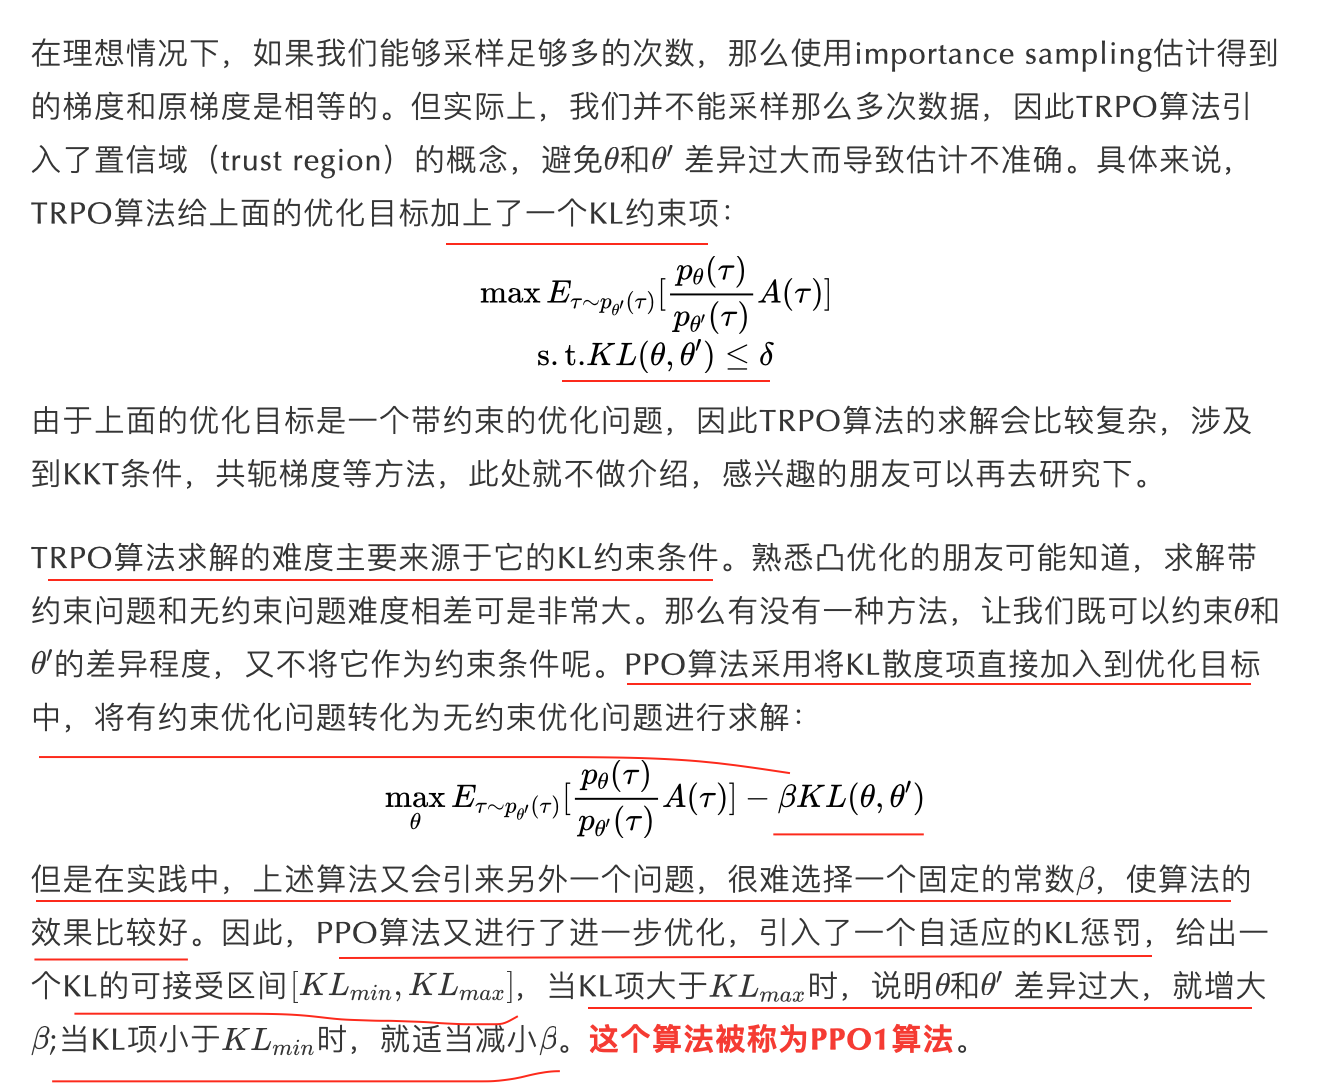

In [25]:
Image(filename='./image/trpo_ppo1.png',width=600)

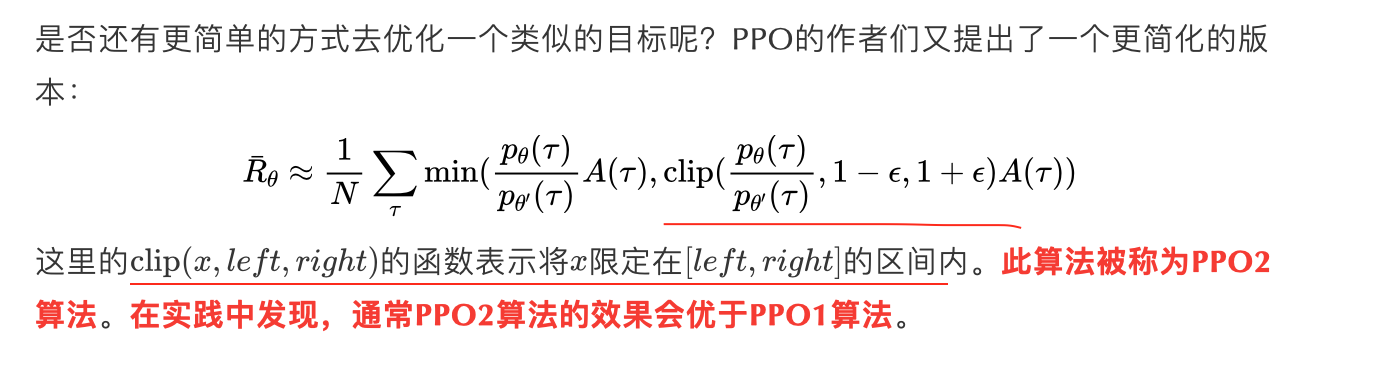

In [26]:
Image(filename='./image/ppo2.png',width=600)

### 上面都是在纯强化背景下的PPO算法，那么在LLM领域，PPO算法又是如何应用的呢？

通常来说，我们会构建四个模型：
- Actor Model：这其实代表的就是agent，在LLM领域里这就是我们需要训练的语言模型；
- Critic Model：它的作用是预估总收益，目的是学习一个值函数;
- Reward Model: 它的目标是计算即时收益，即学习奖励函数；
- Reference Model: 它的作用是给语言模型增加一些约束，防止需要训练的语言模型训歪。

通常来说，在RLHF-PPO阶段:
- Actor/Critic model都是需要训练的，而Reward/Reference Model则参数冻结。
- 我们通常采用下面的方式去初始化这些模型：
  - actor/reference model采用sft阶段训练后的语言模型初始化，
  - critic model和reward model则采用语言模型的backbone + 各自的value head来进行初始化。
 
 一个完整的RLHF-PPO训练过程如下：


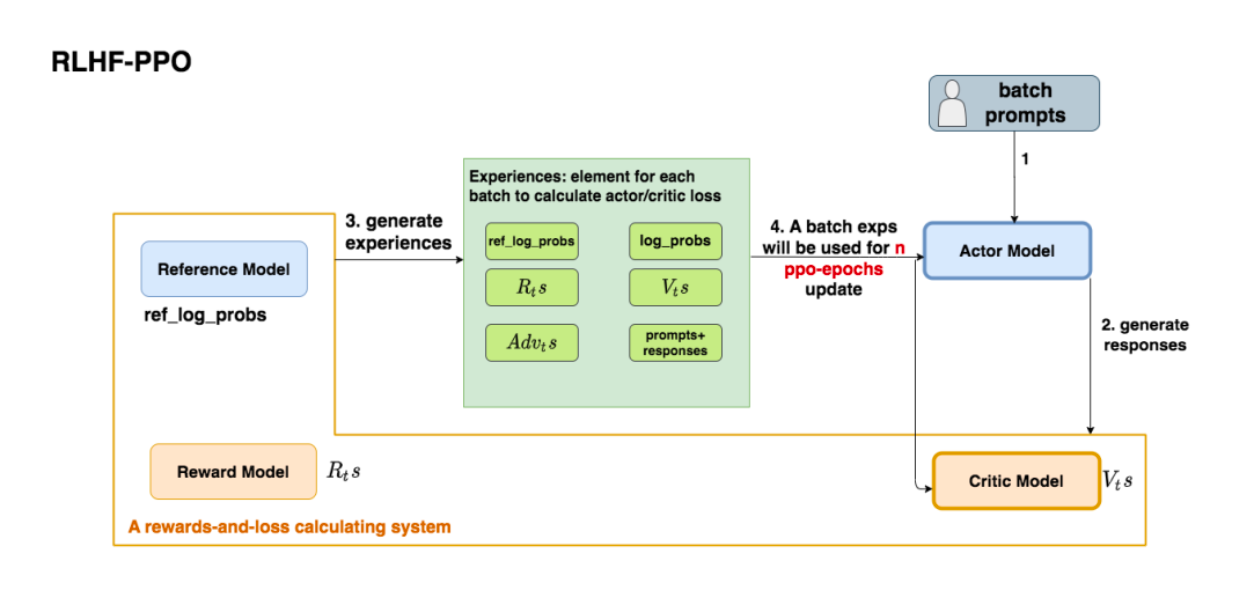

In [27]:
Image(filename='./image/RLHF-PPO.png',width=600)

- 将一个batch的prompts送进Actor语言模型，语言模型产生回答responses；
- 将prompt + responses送进Critic/Reward/Reference Model，
   - 让他们生成用于计算actor/critic loss的数据。
   - 按照强化学习的术语，我们将这些数据称为经验；
- 最后根据这些经验计算出actor/critic loss，然后更新actor和critic model。

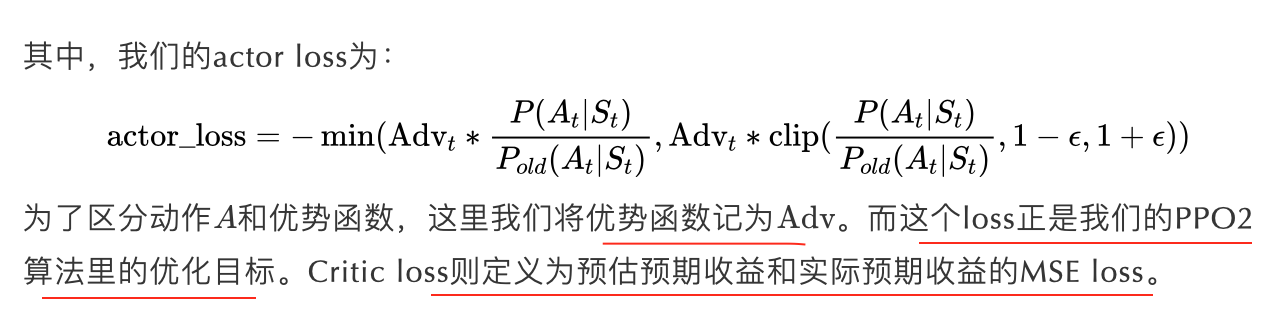

In [28]:
Image(filename='./image/actorloss.png',width=600)

# GRPO算法

铺垫了这么多，终于到我们的核心GRPO算法了。
- 在上面的PPO算法中，我们通常会引入一个critic model（或者称为value model）来判断每个动作的优劣，从而改进策略。
- 但它的引入也同时带来了两个问题：价值函数估计可能不准确，
  - 在LLM的语境里，通常只有一个完整的句子会容易给出一个好坏的判断，而对中间过程生成的token，我们很难给一个准确的奖励值，而价值函数估计不准确则会导致学习策略变差；
  - 其次就是模型显存占用高，消耗计算资源大，因为critic model通常和actor model参数量差不多。
  - 为了解决这个问题，<font color='red'>GRPO算法直接在模型层面删掉了critic model。如下图所示：<font>

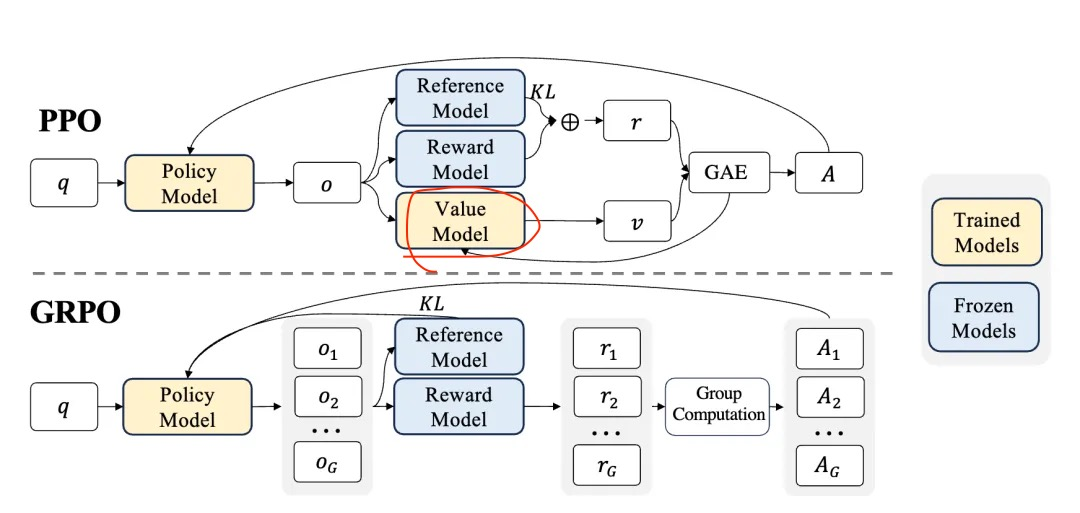

In [30]:
Image(filename='./image/PPO_GRPO.png')

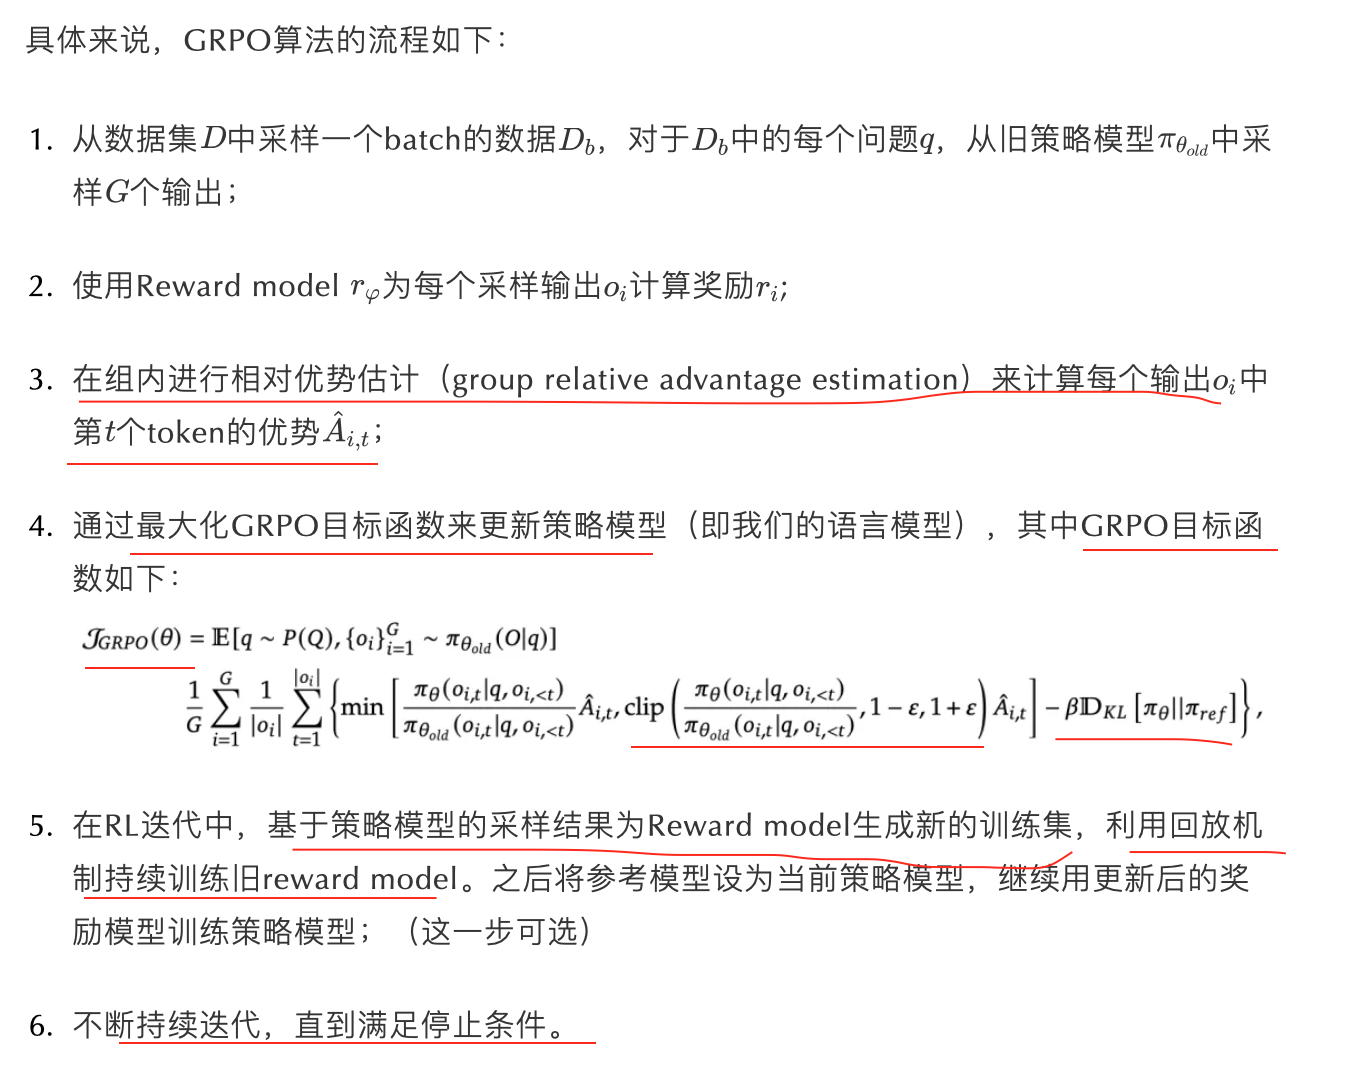

In [32]:
Image(filename='./image/grpo_step.png',width=600)

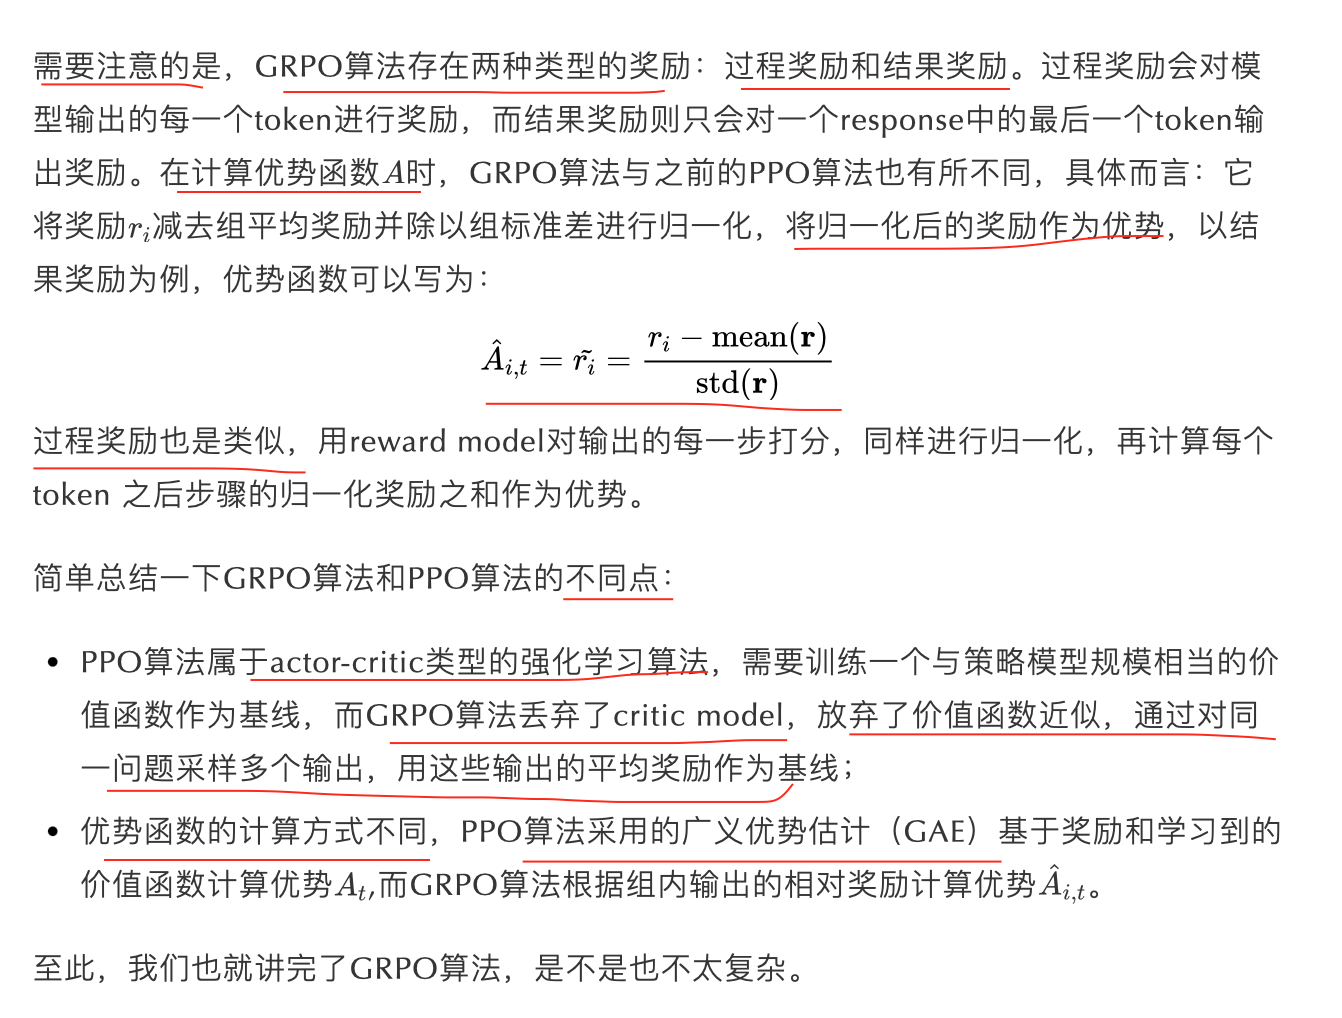

In [33]:
Image(filename='./image/grpo_notice.png',width=600)

# GRPO算法在R1中的应用


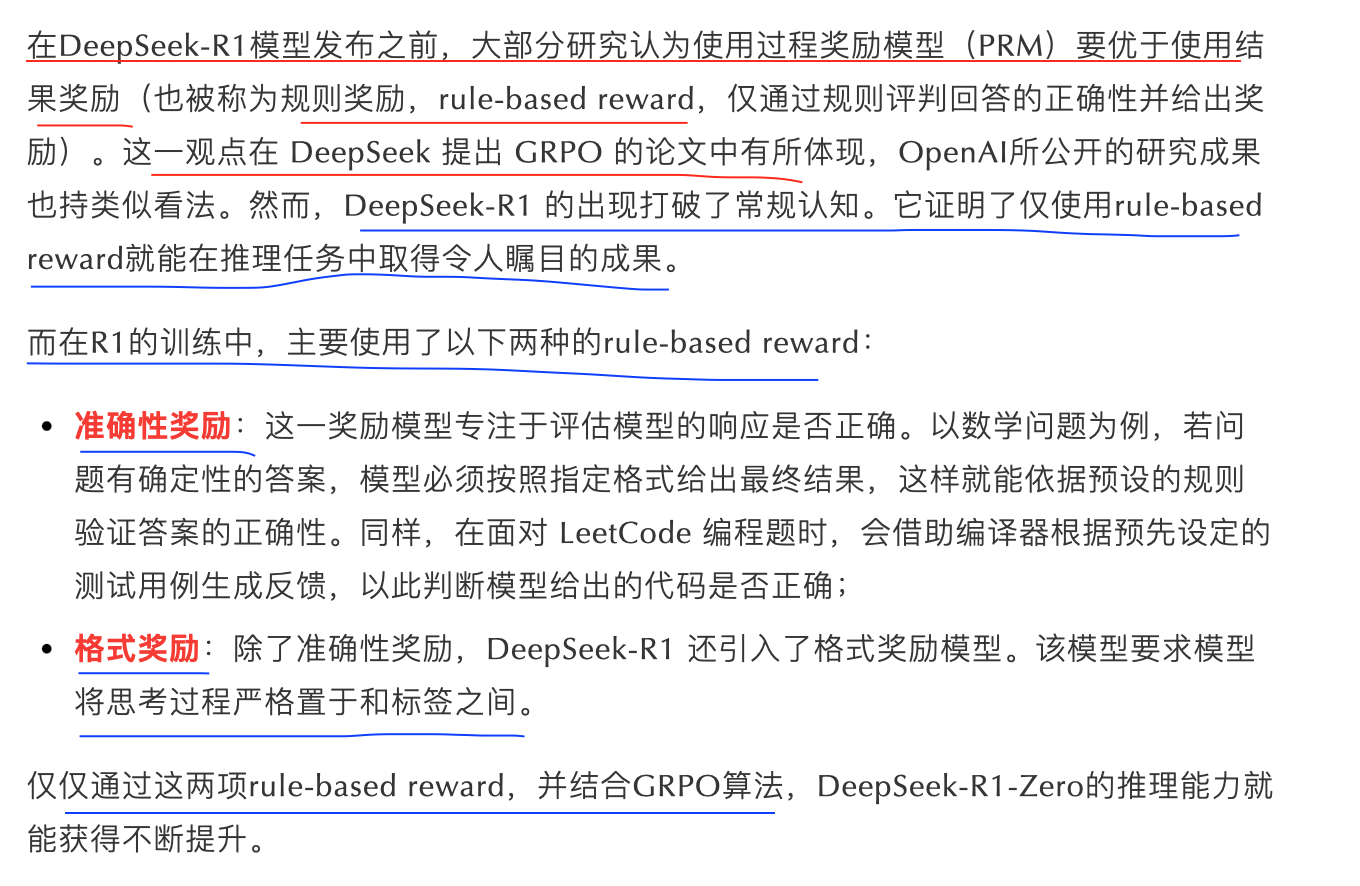

In [35]:
Image(filename='./image/grpo_r1.png',width=600)

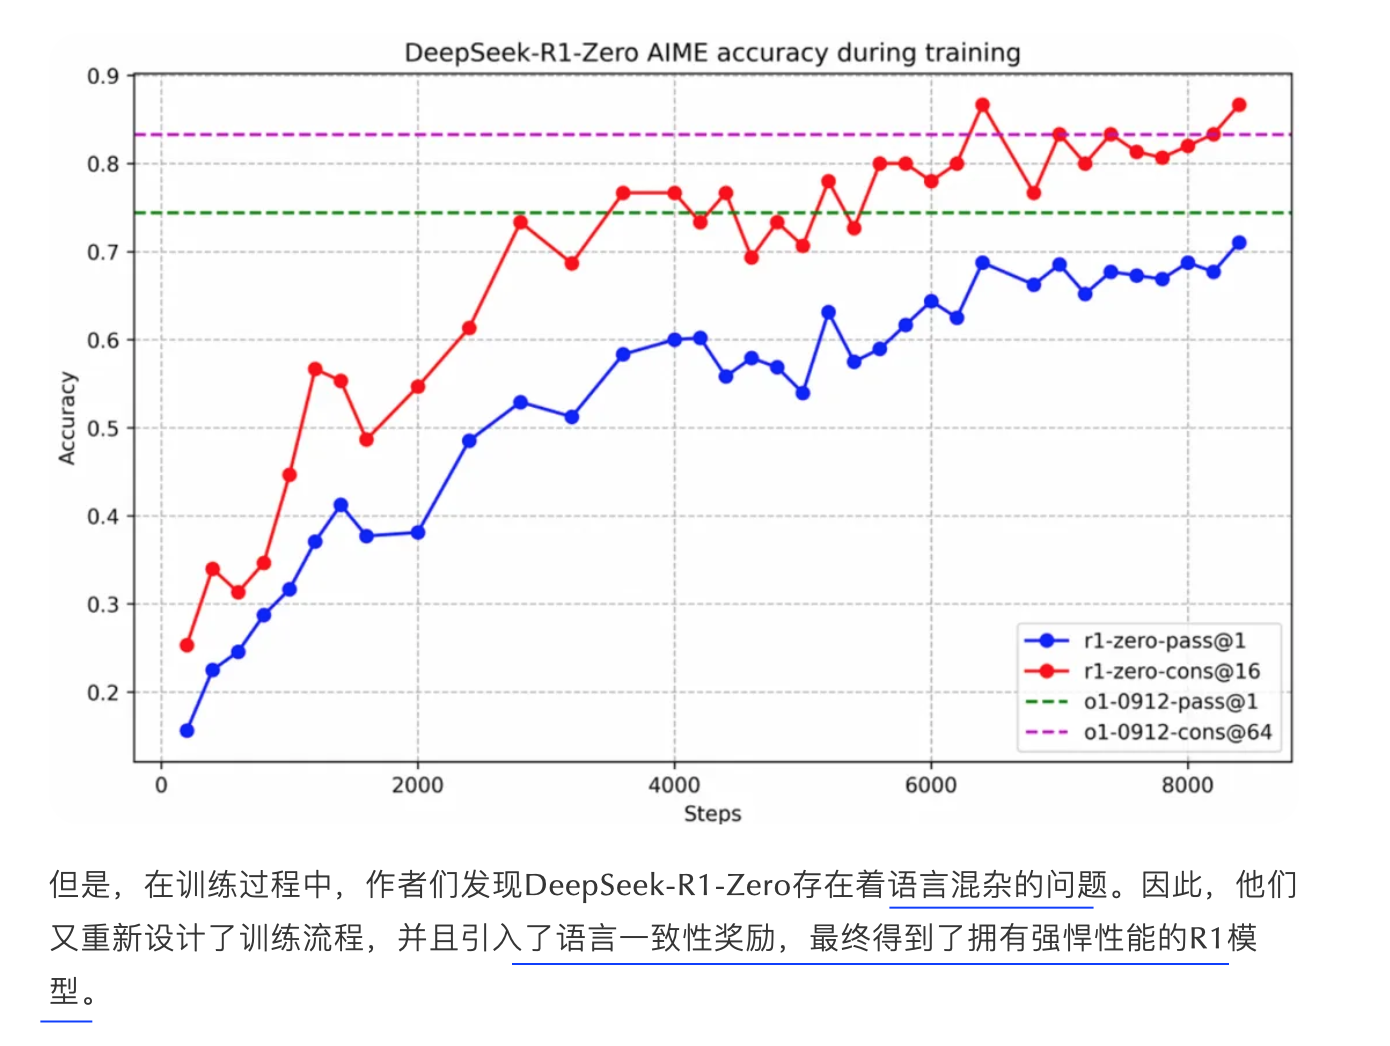

In [36]:
Image(filename='./image/grpo_r1_chart.png',width=600)

# GRPO 公式理解

https://mp.weixin.qq.com/s/J-1Oq_69LPLOm1CtDHbX6w

## GRPO 目标函数详解
### 目标函数定义
- 广义强化学习策略优化（Generalized Reinforcement Learning with Policy Optimization, GRPO）的目标函数如下：

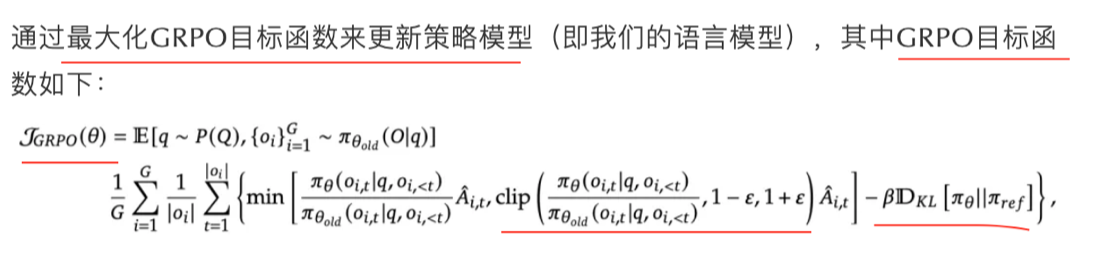

In [37]:
Image(filename='./image/grpo_targe.png',width=600)

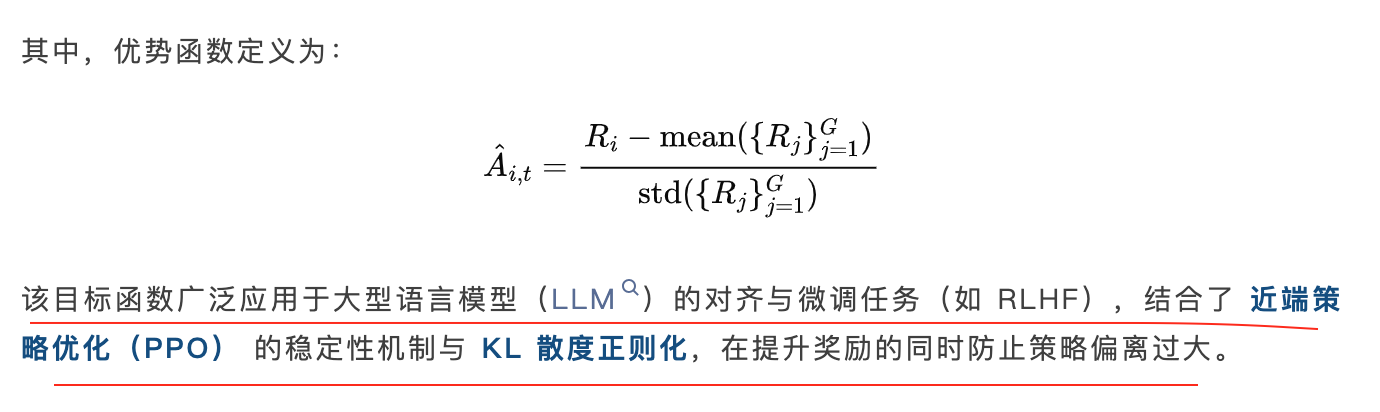

In [39]:
Image(filename='./image/grpo_target02.png',width=600)

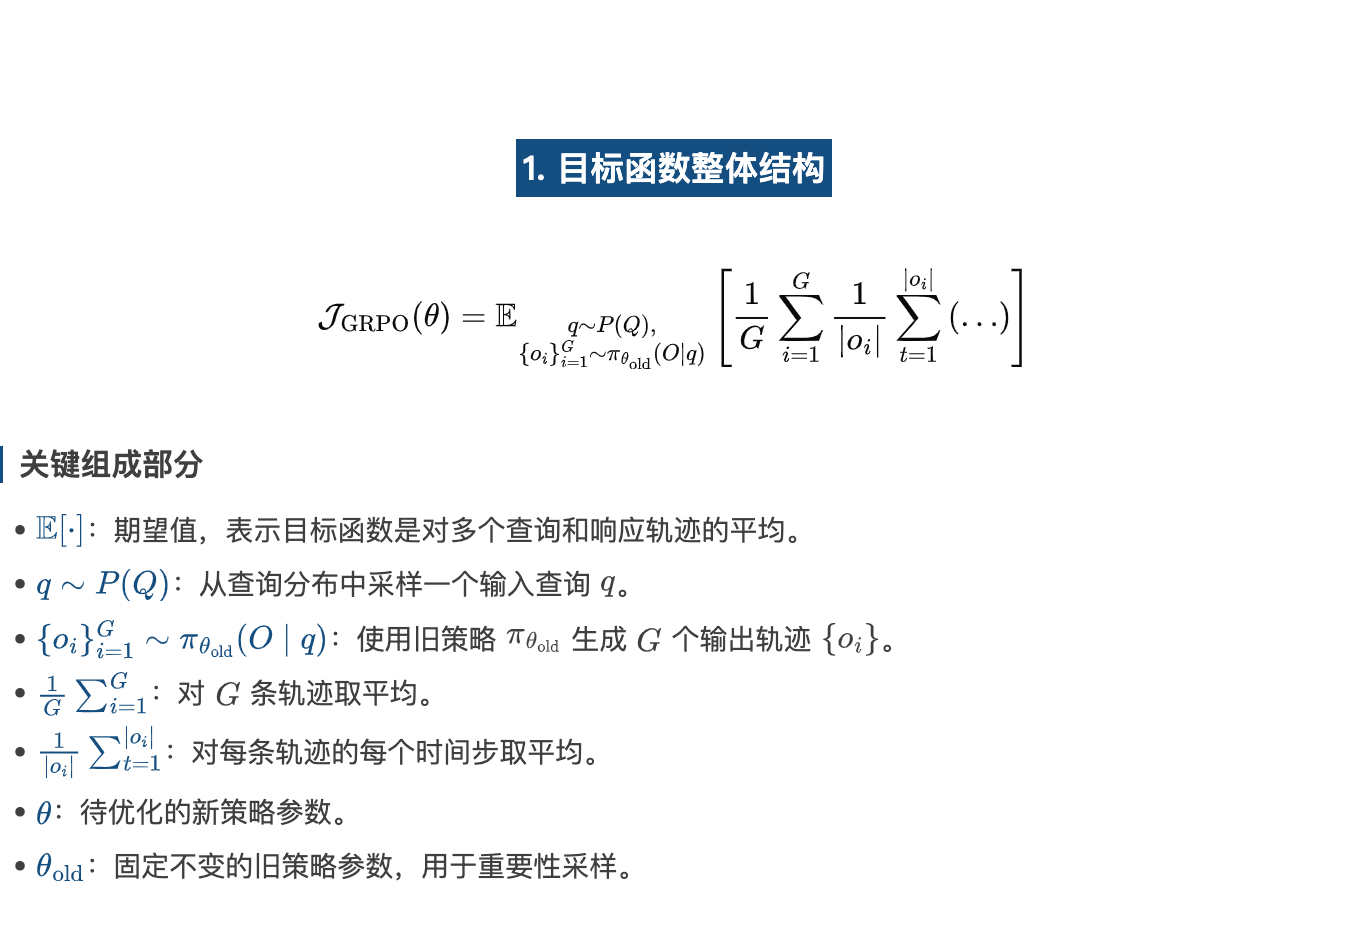

In [40]:
Image(filename='./image/target_arti.png',width=600)

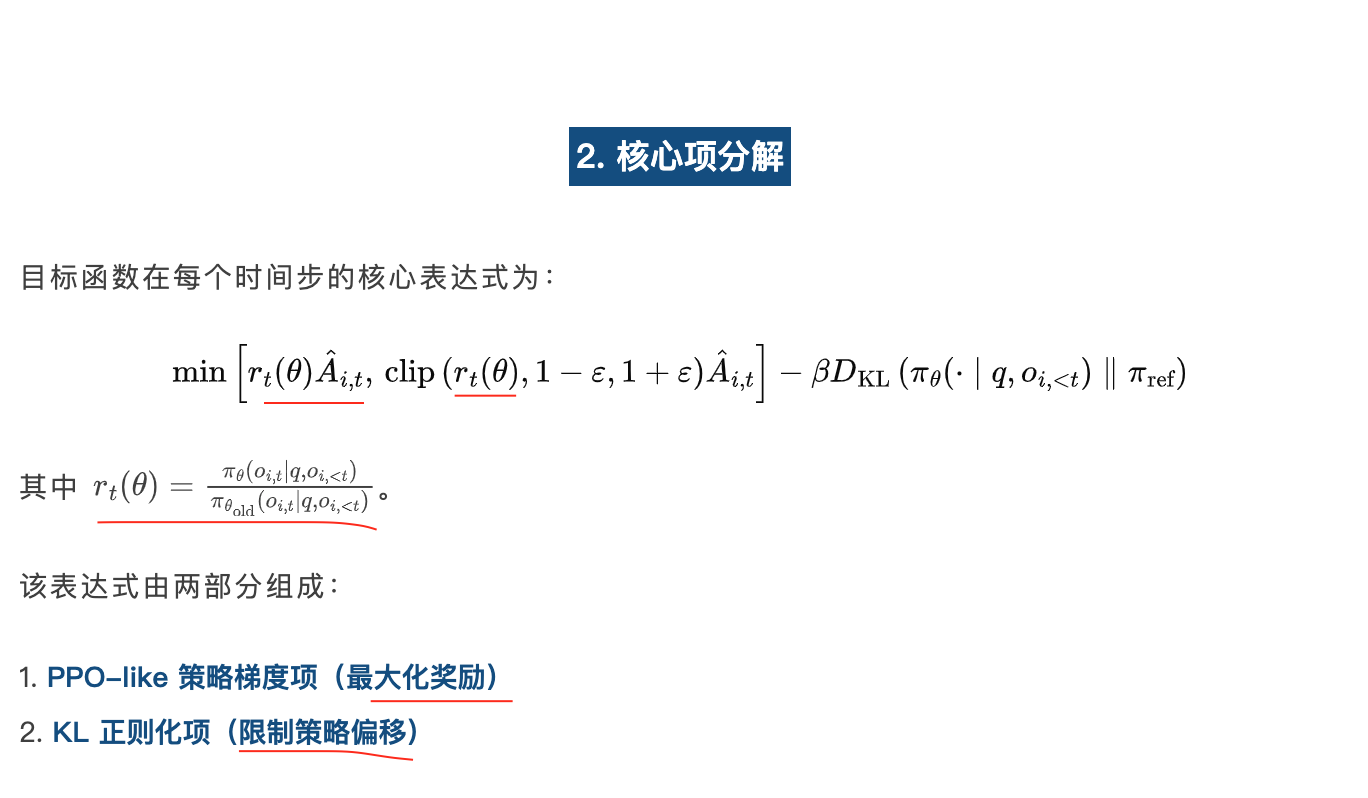

In [49]:
Image(filename='./image/grpo_core_01.png',width=600)

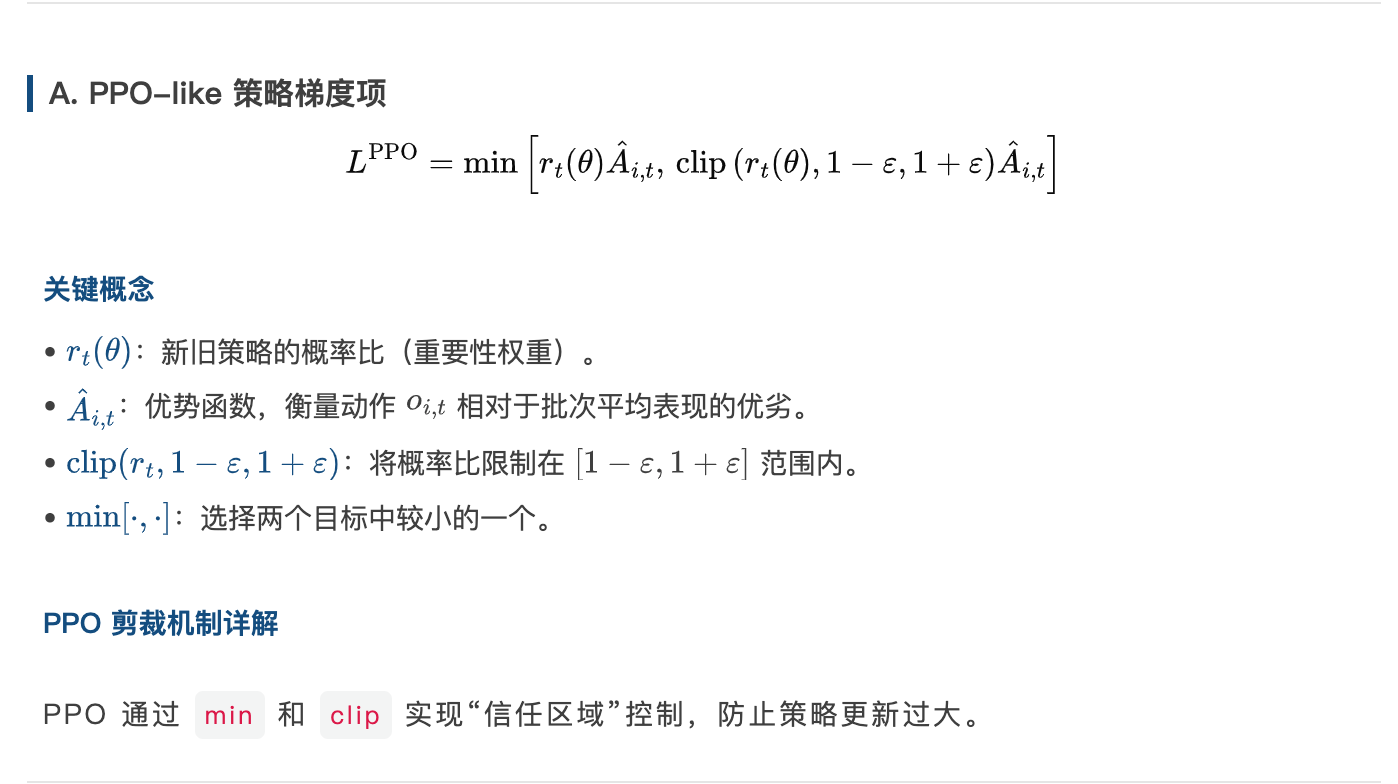

In [42]:
Image(filename='./image/grpo_core_02.png',width=600)

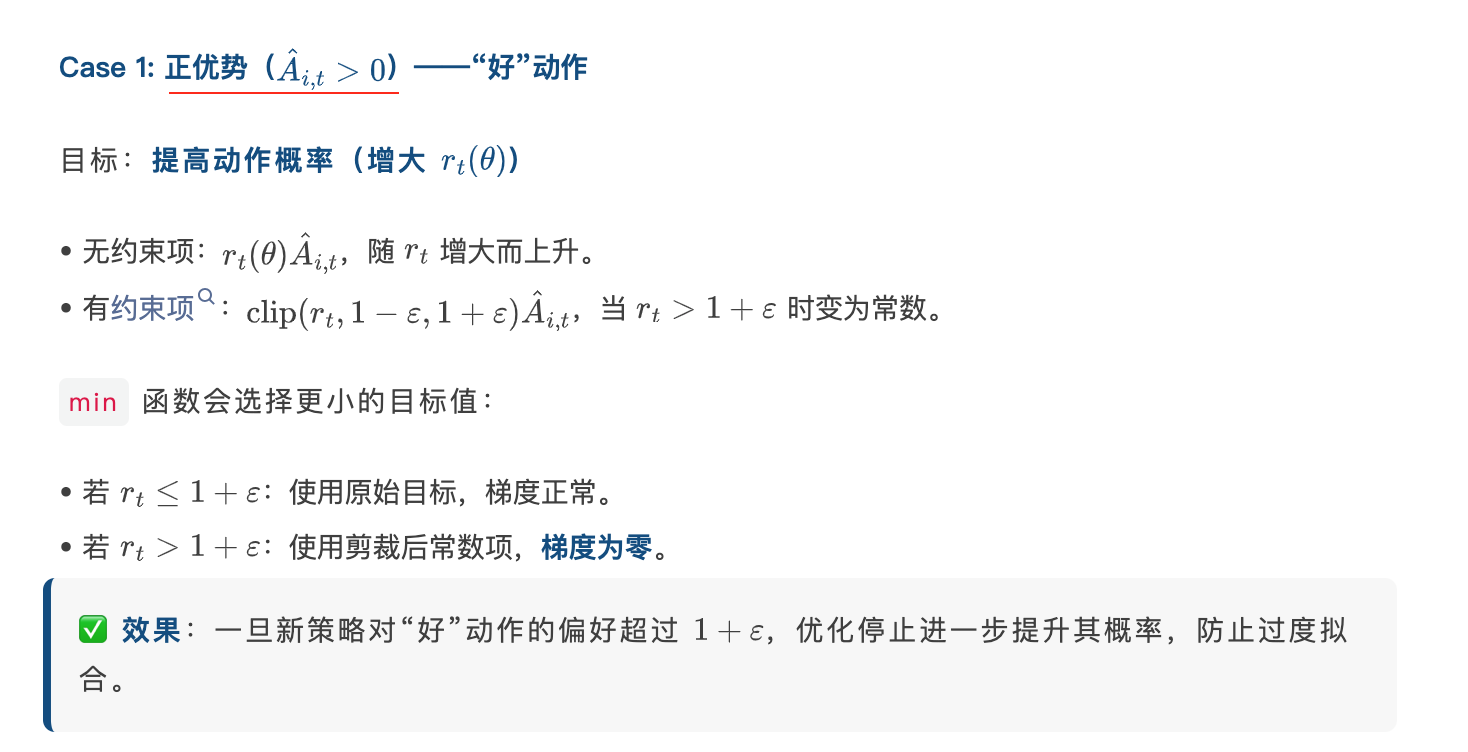

In [50]:
Image(filename='./image/grpo_core_03.png',width=600)

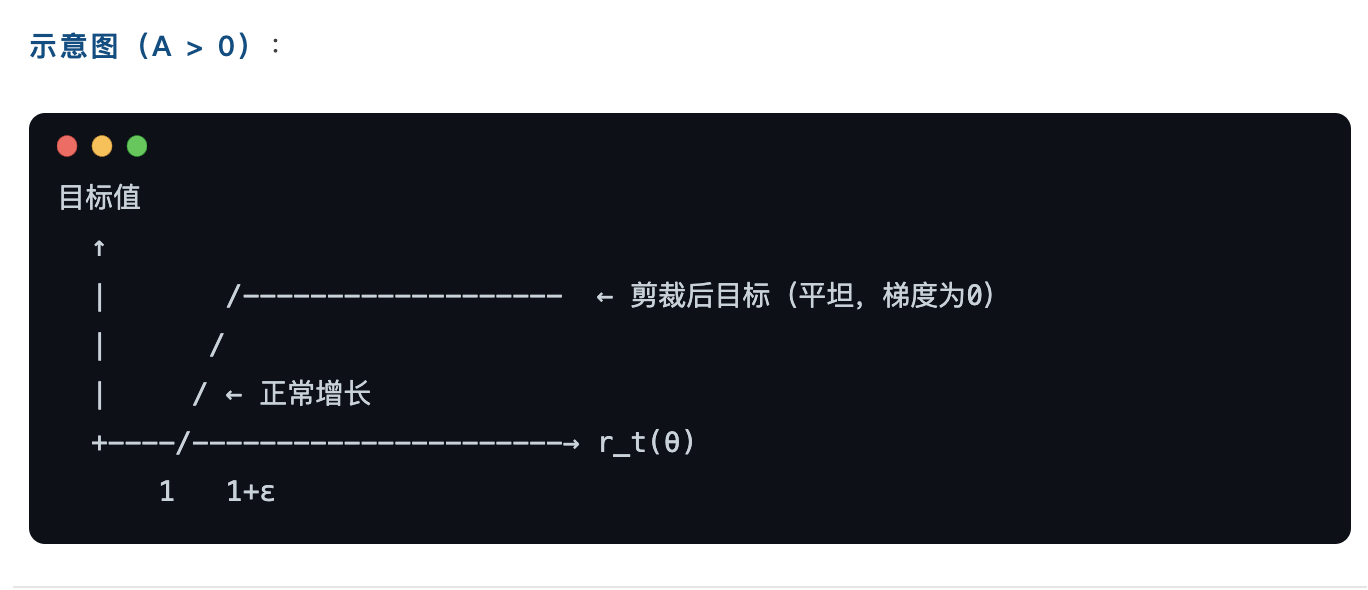

In [44]:
Image(filename='./image/grpo_core_04.png',width=600)

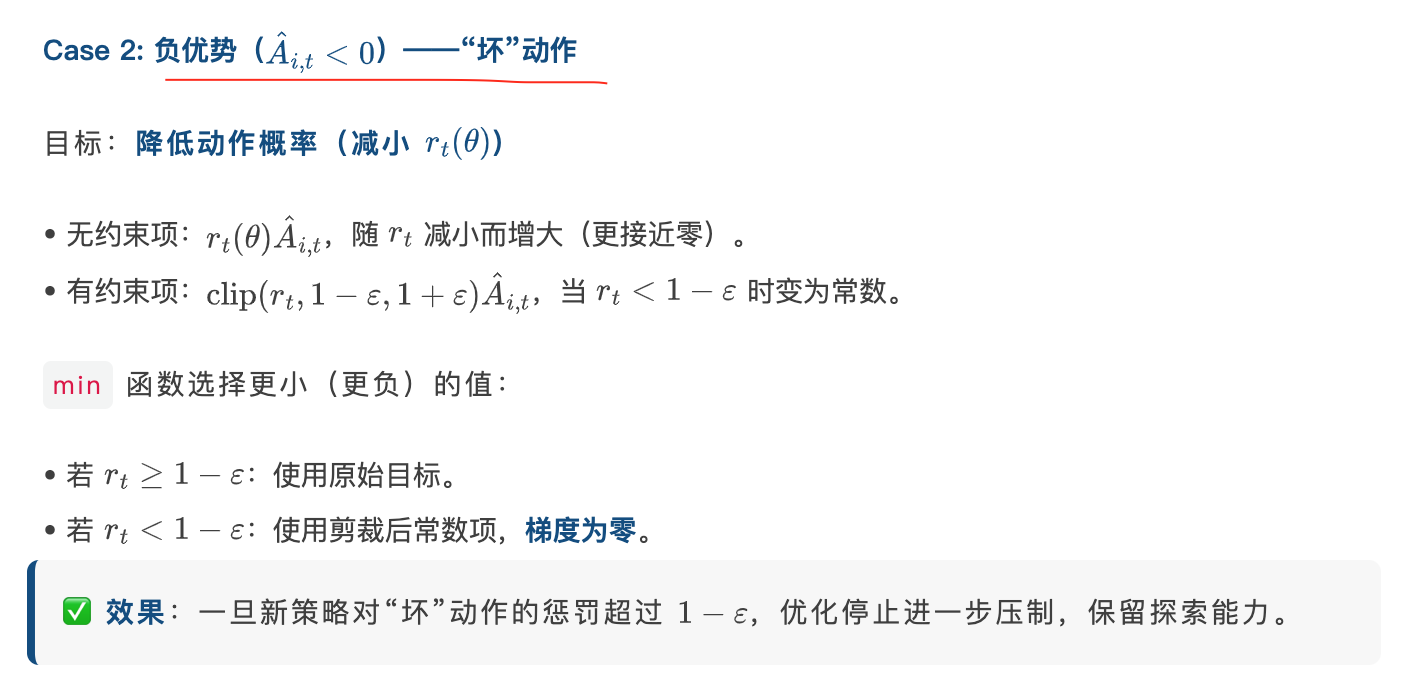

In [51]:
Image(filename='./image/grpo_core_05.png',width=600)

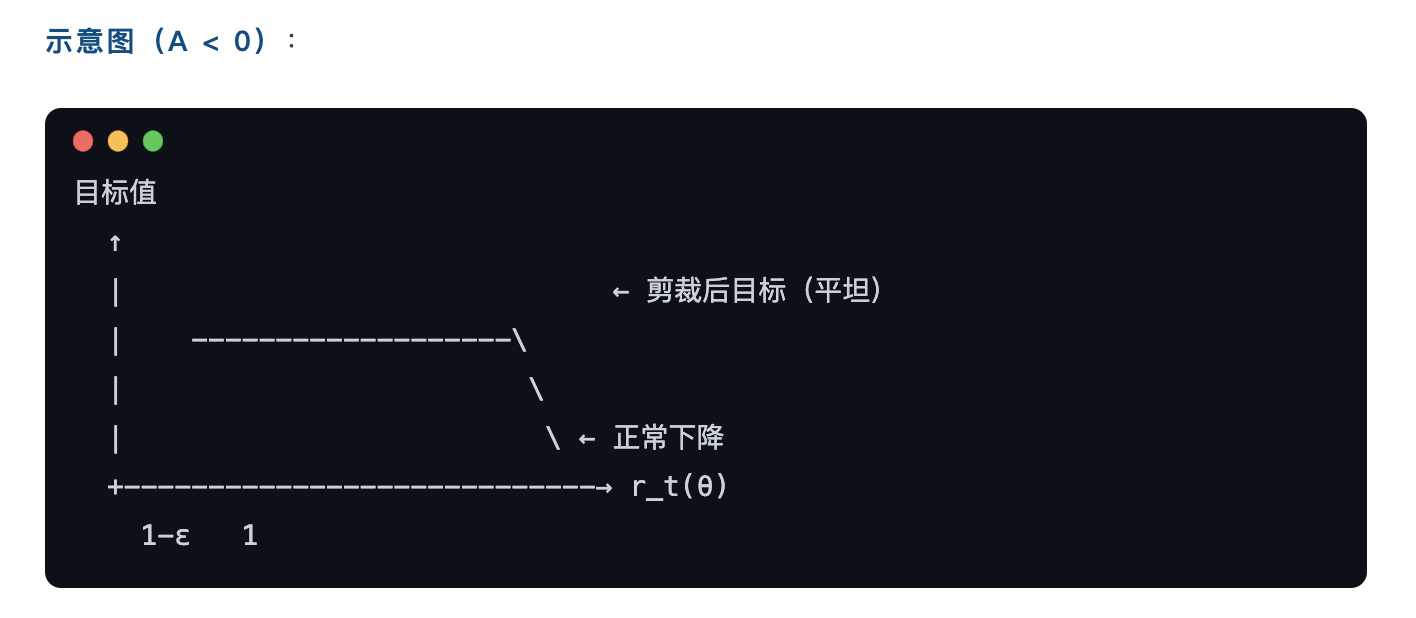

In [46]:
Image(filename='./image/grpo_core_06.png',width=600)

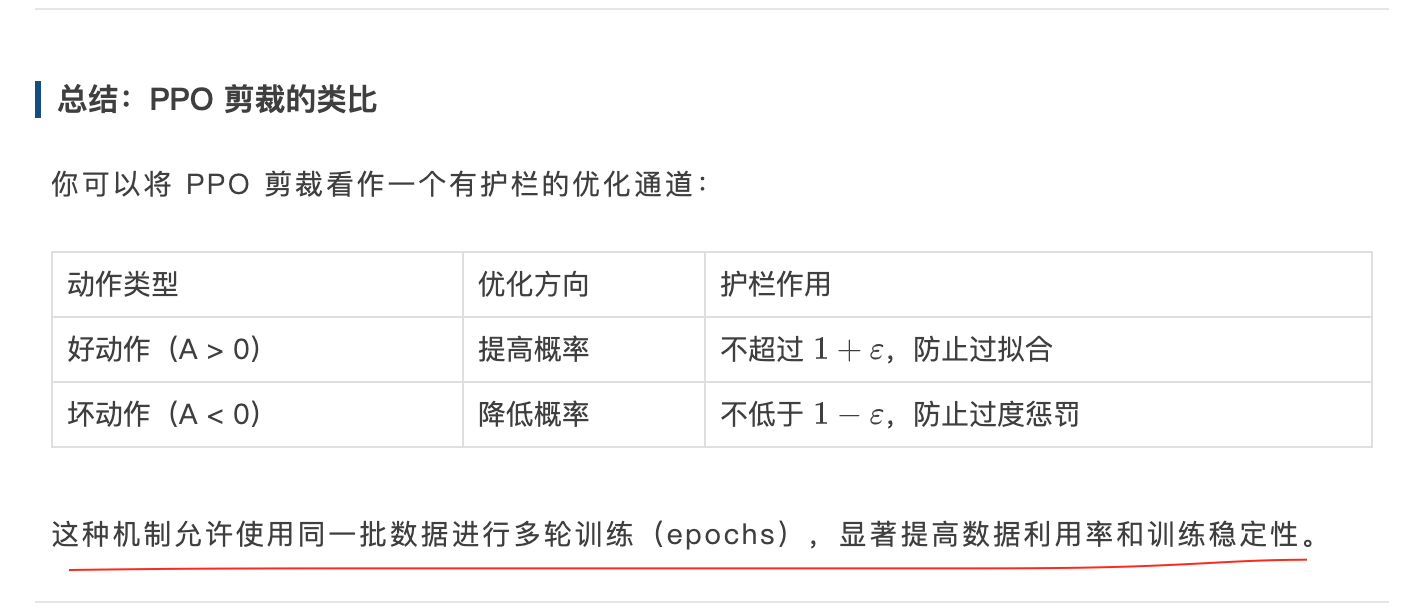

In [52]:
Image(filename='./image/grpo_core_07.png',width=600)

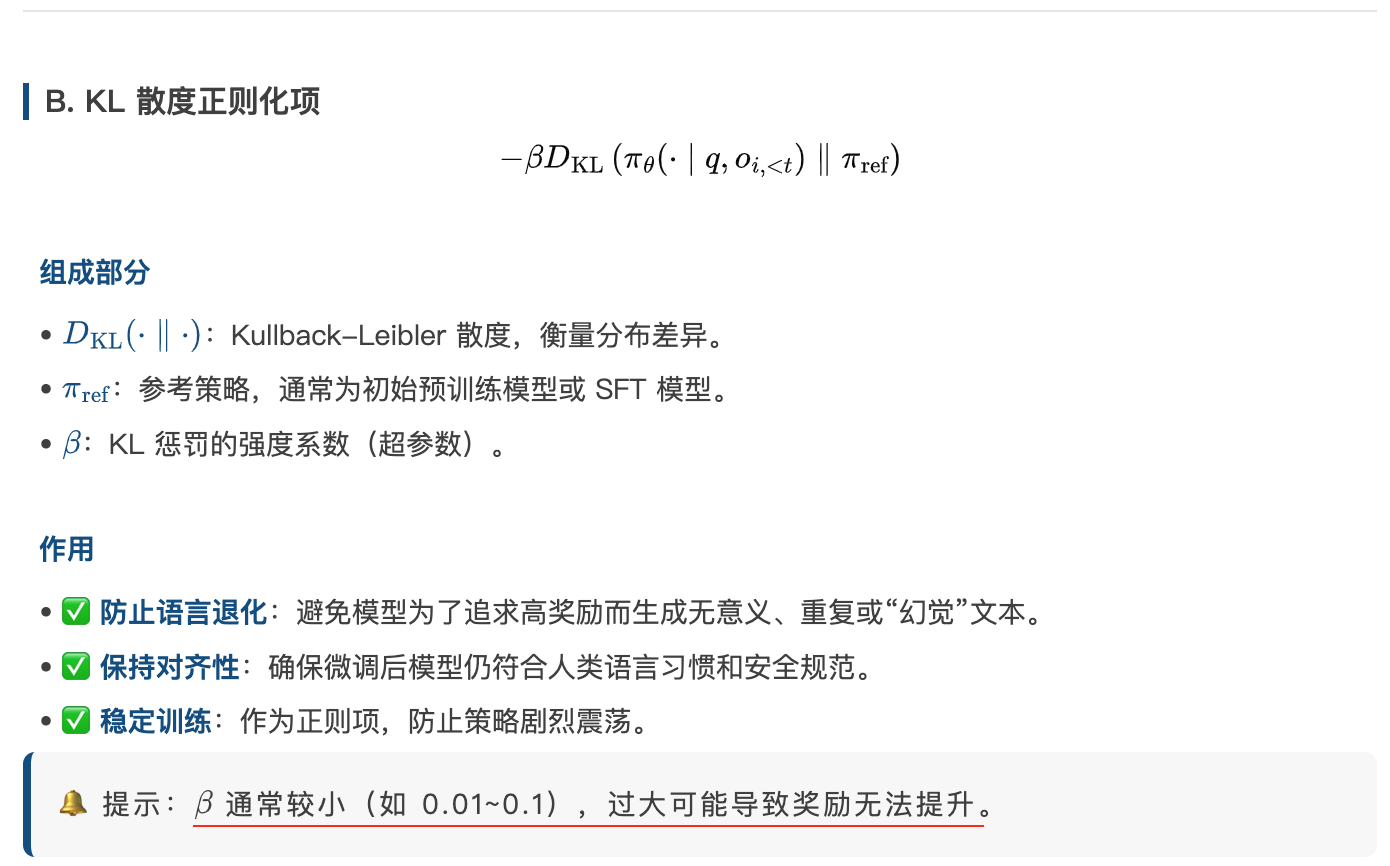

In [54]:
Image(filename='./image/grpo_core_08.png',width=600)

## GRPO在MoE上为什么难以收敛？

### 新旧策略的差异
- 新旧策略可能会激活不同的专家，产生结构性偏差，带来噪声。
- 当从$ π_{θold} 更新到 π_θ $时，很有可能出现 Router 发生变化，导致新旧策略激活了不同的专家。
  - 例如：在 $π_{θold }$下，Router 激活了【专家 A】和【专家 B】
  - 在 $π_θ$ 下，Router 激活了【专家 C】和【专家 D】
- 虽然模型参数只更新了一步，但实际参与计算的专家组合完全不同。所以这两个概率根本不是在同一个“结构”下产生的。
- 理想中的重要性比率应该反映同一个模型结构下，参数变化导致的输出概率变化。但现在它还包含了完全不同的专家组合导致输出的变化。
- 这不是策略变化的真实反映，这种波动具有高方差、不可预测、与优化方向无关的噪声。

### Clip 也无法完全控制这种结构性偏差
- $π_θ 和 π_{θold} $实际上像是两个不同的模型，重要性比率的方差急剧上升，甚至趋于无穷。
- 不同的路由可能会导致 $π_θ$ 骤变，导致 clip 没有任何更新。梯度估计严重失真，训练不稳定甚至崩溃。

### 解决方法解决方法如下：
- Routing Replay
- GSPO

## 为什么 GRPO 容易出现 reward 崩塌？

https://mp.weixin.qq.com/s/3sFmbPDR77FgX5moX3_rhQ

## GSPO和GRPO的区别？

https://mp.weixin.qq.com/s/R6DsZxbHbH5PfxcSlZ-Mkg

## PPO/DPO/GRPO的区别？

https://mp.weixin.qq.com/s/s9hRDu4SZX5JR2SAyRv4zg

## GRPO“第一背锅侠”Token Level X：DAPO/DrGRPO与GSPO/GMPO的殊途同归

https://mp.weixin.qq.com/s/yZ7F59Kw70tAmSONyOHTyA

## PPO、DPO、GRPO及其变体（Dr. GRPO、GSPO、GMPO、LitePPO）策略优化算法综述

https://mp.weixin.qq.com/s/X10NwHRrVeM5flNeXLPSDQ

## 语义熵+RL = 更聪明的大模型！SEED-GRPO 重塑策略优化范式

https://mp.weixin.qq.com/s/R8fh6RKUyJmob9sSoczhbg